In [18]:
import pandas as pd

In [19]:
dataset_full = pd.read_csv("./cars_dataset.csv", encoding="cp1252")

filtered = dataset_full[
    dataset_full["Company Names"].isin(
        [
            "TOYOTA",
            "VOLVO",
            "Toyota",
            "Volvo",
            "BMW",
            "Tesla",
            "Volkswagen",
        ]
    )
]

df_sample = filtered.sample(n=12, random_state=123)

In [20]:
df = df_sample.drop(columns=["Engines", "Fuel Types"])

cols = [
    "CC/Battery Capacity",
    "HorsePower",
    "Total Speed",
    "Performance(0 - 100 )KM/H",
    "Cars Prices",
    "Seats",
    "Torque"
]

df[cols] = df[cols].apply(
    lambda col: col.astype(str)
    .str.replace(',', '')
    .str.extract(r'(\d+\.?\d*)')[0]
).astype(float)

int_cols = cols.copy()
int_cols.remove("Performance(0 - 100 )KM/H")

df[int_cols] = df[int_cols].astype(int)
df.reset_index(drop=True, inplace=True)


In [21]:
df

,Company Names,Cars Names,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Seats,Torque
0,Volkswagen,Golf 4MOTION,1968,150,250,4.9,40000,5,400
1,Volvo,Volvo VNR,12800,400,110,17.0,95000,2,1800
2,TOYOTA,GR COROLLA,1618,300,230,5.0,36995,5,370
3,BMW,M550i XDRIVE,4395,523,250,3.6,78000,5,650
4,TOYOTA,INNOVA HYCROSS,1987,184,165,9.5,40000,7,250
5,Volkswagen,Passat Hybrid,1395,215,210,7.4,32000,5,330
6,Tesla,Model X,100,670,250,3.8,98490,7,967
7,Volkswagen,Jetta Hybrid,1395,170,210,8.6,28000,5,250
8,Volvo,Volvo FMX,13000,500,110,16.5,110000,2,2500
9,Volkswagen,Passat,1984,150,210,7.8,25000,5,250


# 2.1


In [22]:
from pulp import *

prefs = [
    (3, 6, '>'), (3, 2, '>'), (3, 0, '>'),
    (6, 2, '>'), (6, 0, '>'), (6, 10, '>'),
    (2, 10, '>'), (0, 10, '>'),
    (10, 3, '>'),
    (0, 2, '~') 
]

gain = ['CC/Battery Capacity', 'HorsePower',
       'Total Speed',  'Seats',
       'Torque']

cost = ['Performance(0 - 100 )KM/H', 'Cars Prices']
criteria = gain + cost


In [23]:

def generate_levels(min_val, max_val, gamma):
    return [
        min_val + (j / (gamma - 1)) * (max_val - min_val)
        for j in range(gamma)
    ]

criterion_values = {}
gamma = 4

for c in criteria:
    min_val = df[c].min()
    max_val = df[c].max()
    criterion_values[c] = generate_levels(min_val, max_val, gamma)

In [24]:
def solve(forbidden=[]):
    prob = LpProblem("UTA", LpMinimize)

    u = {}
    # marginal utilities
    for c in criteria:
        u[c] = {}
        for val in criterion_values[c]:
            u[c][val] = LpVariable(f"u_{c}_{val}", 0, 1)

    # monotonicity
    for c in criteria:
        vals = criterion_values[c]
        for i in range(len(vals)-1):
            if c in cost:
                prob += u[c][vals[i]] >= u[c][vals[i+1]]
            else:
                prob += u[c][vals[i]] <= u[c][vals[i+1]]

    #normalization
    for c in criteria:
        vals = criterion_values[c]
        if c in cost:
            prob += u[c][vals[-1]] == 0
        else:
            prob += u[c][vals[0]] == 0

    # weight constraints
    weights = {}
    for c in criteria:
        vals = criterion_values[c]
        if c in cost:
            weights[c] = u[c][vals[0]]
        else:
            weights[c] = u[c][vals[-1]]
        prob += weights[c] <= 0.5
        prob += weights[c] >= 0.1


    prob += lpSum(weights[c] for c in criteria) == 1

    def marginal_utility(c, val):
        vals = sorted(criterion_values[c])

        for j in range(len(vals) - 1):
            xj = vals[j]
            xj1 = vals[j+1]

            if xj <= val <= xj1:
                return (
                    u[c][xj] +
                    (val - xj) / (xj1 - xj) *
                    (u[c][xj1] - u[c][xj])
                )

        return u[c][vals[-1]]


    def utility(i):
        return lpSum(
            marginal_utility(c, df.loc[i, c])
            for c in criteria
        )

    epsilon = 0.01
    M = 10

    y = {}

    for k, (a, b, rel) in enumerate(prefs):
        y[k] = LpVariable(f"y_{k}", cat="Binary")

        if rel == '>':
            prob += utility(a) >= utility(b) + epsilon - M * y[k]

        elif rel == '~':
            prob += utility(a) >= utility(b) - M * y[k]
            prob += utility(a) <= utility(b) + M * y[k]
        
    for forbidden_variables in forbidden:
        prob += lpSum([y[k] for k in forbidden_variables]) <= len(forbidden_variables) - 1

    prob += lpSum(y[k] for k in y)

    #prob.solve(PULP_CBC_CMD(msg=0))
    prob.solve(GLPK_CMD(path="/opt/homebrew/bin/glpsol", msg=0)) #for mac
    return prob, y, criteria, weights, u


In [25]:
def print_results(prob, y, criteria, weights):
    print("Status: ", LpStatus[prob.status])
    
    print("Violated constraints:")
    violated = []
    for k in y:
        if value(y[k]) == 1:
            print(f"Removed: {prefs[k]}")
            violated.append(k)
            
    print("Consistent preference subset:")
    for k in range(len(prefs)):
        if k not in violated:
            print(prefs[k])

    print("Weights:")
    for c in criteria:
        print(c, round(value(weights[c]),3))
    


In [26]:
res = solve()
prob, y, criteria, weights, u = res
print_results(prob, y, criteria, weights)


violated = [k for k in y if value(y[k]) == 1]
consistent_prefs = [prefs[k] for k in range(len(prefs)) if k not in violated] # for 2.2


Status:  Optimal
Violated constraints:
Removed: (10, 3, '>')
Consistent preference subset:
(3, 6, '>')
(3, 2, '>')
(3, 0, '>')
(6, 2, '>')
(6, 0, '>')
(6, 10, '>')
(2, 10, '>')
(0, 10, '>')
(0, 2, '~')
Weights:
CC/Battery Capacity 0.1
HorsePower 0.1
Total Speed 0.1
Seats 0.1
Torque 0.1
Performance(0 - 100 )KM/H 0.14
Cars Prices 0.36


In [27]:
import matplotlib.pyplot as plt

def plot_criterion(prob, u, criterion, criterion_values, utility_min=0, utility_max=0.5):
    x_vals = criterion_values[criterion]
    y_vals = [u[criterion][v].varValue for v in x_vals]

    plt.figure(figsize=(8, 6))
    plt.plot(
        x_vals,
        y_vals,
        marker='o',
        linestyle='-',
        label=fr'$u(g_{{{criterion}}})$'
    )
    plt.xlabel(fr'$g_{{{criterion}}}$')
    plt.ylabel(fr'$u(g_{{{criterion}}})$')
    plt.title(f'Partial utility function for criterion {criterion}')
    plt.xticks(x_vals)
    plt.ylim(utility_min, utility_max)
    plt.grid(True)
    plt.legend()
    plt.show()

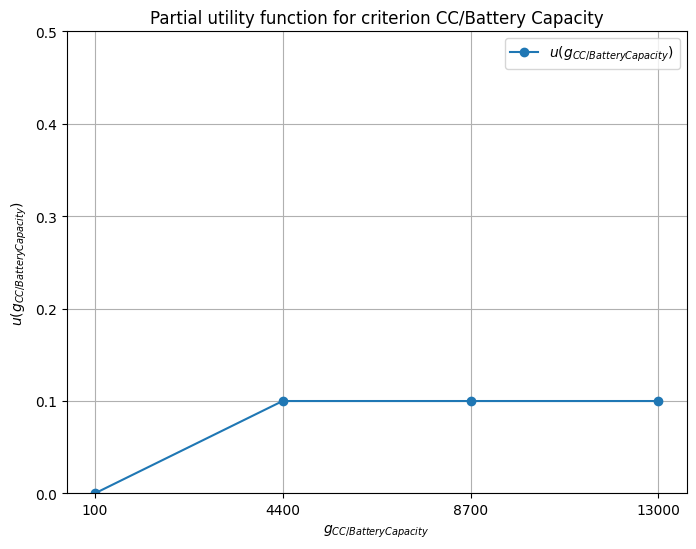

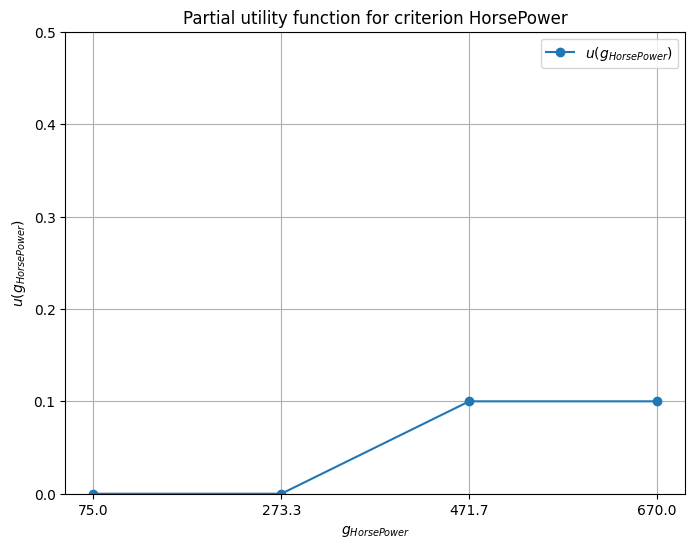

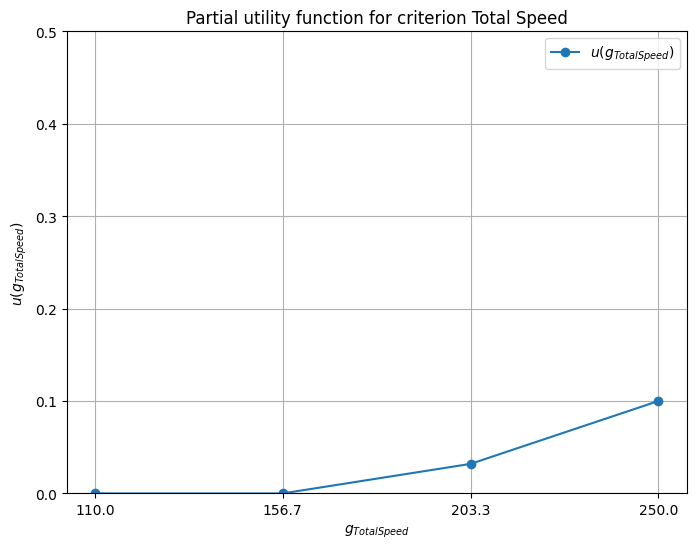

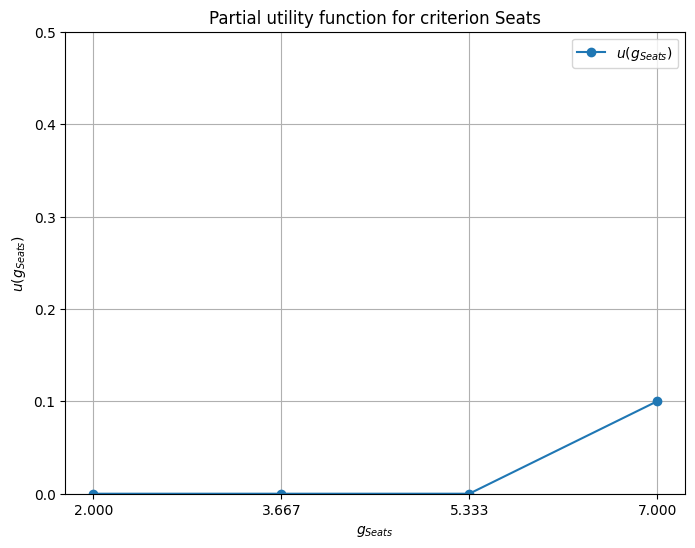

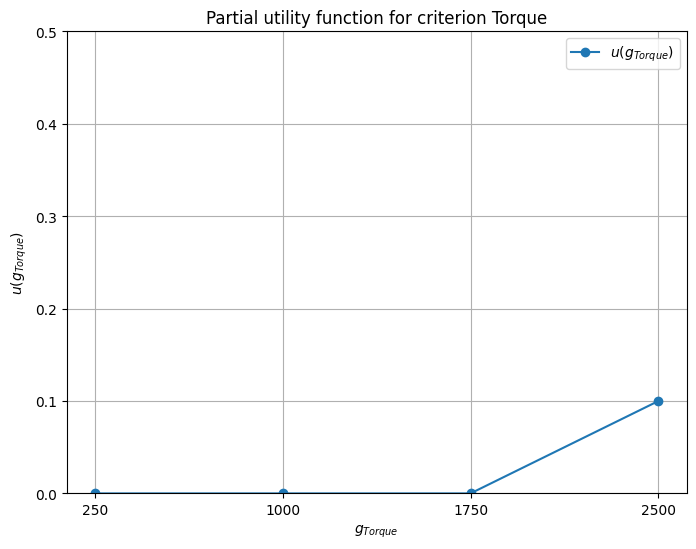

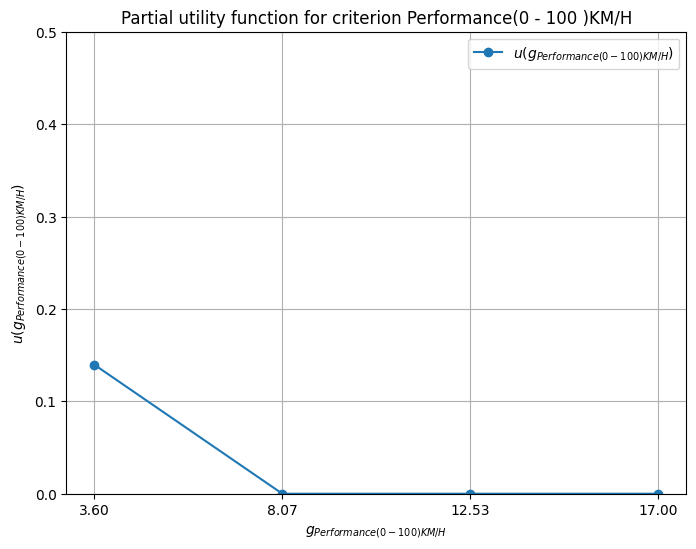

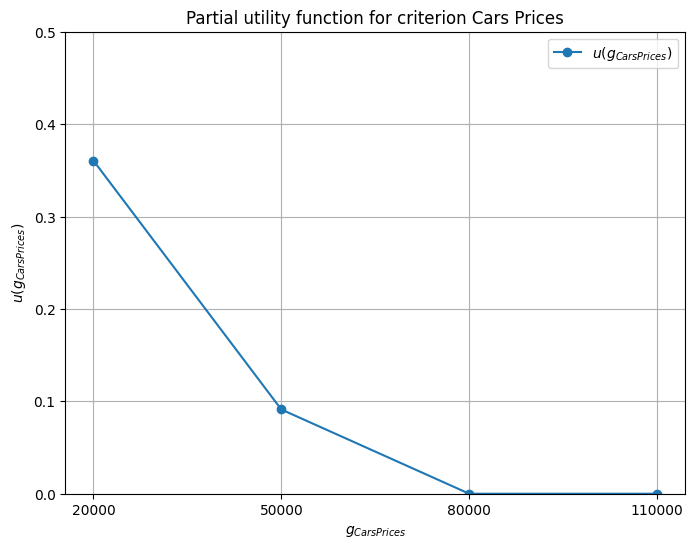

In [28]:
for criterion in criteria:
    plot_criterion(prob, u, criterion, criterion_values)

In [29]:
forbidden = []
while True:
    res = solve(forbidden)
    prob, y, criteria, weights, u = res
    if LpStatus[prob.status] != "Optimal":
        break
    forbidden.append([k for k in y if value(y[k]) == 1])
    print(forbidden)
    print_results(prob, y, criteria, weights)

[[8]]
Status:  Optimal
Violated constraints:
Removed: (10, 3, '>')
Consistent preference subset:
(3, 6, '>')
(3, 2, '>')
(3, 0, '>')
(6, 2, '>')
(6, 0, '>')
(6, 10, '>')
(2, 10, '>')
(0, 10, '>')
(0, 2, '~')
Weights:
CC/Battery Capacity 0.1
HorsePower 0.1
Total Speed 0.1
Seats 0.1
Torque 0.1
Performance(0 - 100 )KM/H 0.14
Cars Prices 0.36
[[8], [0, 6, 7]]
Status:  Optimal
Violated constraints:
Removed: (3, 6, '>')
Removed: (2, 10, '>')
Removed: (0, 10, '>')
Consistent preference subset:
(3, 2, '>')
(3, 0, '>')
(6, 2, '>')
(6, 0, '>')
(6, 10, '>')
(10, 3, '>')
(0, 2, '~')
Weights:
CC/Battery Capacity 0.1
HorsePower 0.137
Total Speed 0.1
Seats 0.1
Torque 0.1
Performance(0 - 100 )KM/H 0.1
Cars Prices 0.363
[[8], [0, 6, 7], [5, 6, 7]]
Status:  Optimal
Violated constraints:
Removed: (6, 10, '>')
Removed: (2, 10, '>')
Removed: (0, 10, '>')
Consistent preference subset:
(3, 6, '>')
(3, 2, '>')
(3, 0, '>')
(6, 2, '>')
(6, 0, '>')
(10, 3, '>')
(0, 2, '~')
Weights:
CC/Battery Capacity 0.1
HorseP

# 2.2

In [30]:
prob = LpProblem("UTA_discriminant", LpMaximize)

u = {}
for c in criteria:
    u[c] = {}
    for val in criterion_values[c]:
        u[c][val] = LpVariable(f"u_{c}_{val}", 0, 1)

for c in criteria:
    vals = criterion_values[c]
    for i in range(len(vals)-1):
        if c in cost:
            prob += u[c][vals[i]] >= u[c][vals[i+1]]
        else:
            prob += u[c][vals[i]] <= u[c][vals[i+1]]

for c in criteria:
    vals = criterion_values[c]
    if c in cost:
        prob += u[c][vals[-1]] == 0
    else:
        prob += u[c][vals[0]] == 0

weights = {}
for c in criteria:
    vals = criterion_values[c]
    if c in cost:
        weights[c] = u[c][vals[0]]
    else:
        weights[c] = u[c][vals[-1]]
    prob += weights[c] <= 0.5
    prob += weights[c] >= 0.1
prob += lpSum(weights[c] for c in criteria) == 1

def marginal_utility(c, val):
    vals = sorted(criterion_values[c])
    for j in range(len(vals)-1):
        xj = vals[j]
        xj1 = vals[j+1]
        if xj <= val <= xj1:
            return u[c][xj] + (val - xj) / (xj1 - xj) * (u[c][xj1] - u[c][xj])
    return u[c][vals[-1]]

def utility(i):
    return lpSum(marginal_utility(c, df.loc[i,c]) for c in criteria)

epsilon = 0.01
for (a, b, rel) in consistent_prefs:
    if rel == '>':
        prob += utility(a) >= utility(b) + epsilon
    elif rel == '~':
        prob += utility(a) == utility(b)

prob += lpSum(utility(a) - utility(b) for (a,b,rel) in consistent_prefs if rel == '>')

prob.solve(GLPK_CMD(path="/opt/homebrew/bin/glpsol", msg=0))

1

In [31]:
print("=== VARIABLES AND THEIR VALUES ===\n")
for v in prob.variables():
    print(f"{v.name} = {v.varValue}")

=== VARIABLES AND THEIR VALUES ===

u_CC_Battery_Capacity_100.0 = 0.0
u_CC_Battery_Capacity_13000.0 = 0.1
u_CC_Battery_Capacity_4400.0 = 0.0999999999999998
u_CC_Battery_Capacity_8700.0 = 0.0999999999999998
u_Cars_Prices_110000.0 = 0.0
u_Cars_Prices_20000.0 = 0.1
u_Cars_Prices_50000.0 = 0.0999999999999999
u_Cars_Prices_80000.0 = 0.1
u_HorsePower_273.3333333333333 = 0.00708659588942741
u_HorsePower_471.66666666666663 = 0.4
u_HorsePower_670.0 = 0.4
u_HorsePower_75.0 = 0.0
u_Performance(0___100_)KM_H_12.533333333333333 = 0.0
u_Performance(0___100_)KM_H_17.0 = 0.0
u_Performance(0___100_)KM_H_3.6 = 0.1
u_Performance(0___100_)KM_H_8.066666666666666 = 0.0
u_Seats_2.0 = 0.0
u_Seats_3.6666666666666665 = 0.0
u_Seats_5.333333333333333 = 0.0
u_Seats_7.0 = 0.1
u_Torque_1000.0 = 0.0999999999999999
u_Torque_1750.0 = 0.0999999999999999
u_Torque_250.0 = 0.0
u_Torque_2500.0 = 0.1
u_Total_Speed_110.0 = 0.0
u_Total_Speed_156.66666666666666 = 0.0
u_Total_Speed_203.33333333333331 = 0.0
u_Total_Speed_250.0 = 

In [32]:
print("\n=== CONSTRAINTS AND EQUATIONS ===\n")
for name, c in prob.constraints.items():
    print(f"{name}: {c}")


=== CONSTRAINTS AND EQUATIONS ===

_C1: u_CC_Battery_Capacity_100.0 - u_CC_Battery_Capacity_4400.0 <= 0
_C2: u_CC_Battery_Capacity_4400.0 - u_CC_Battery_Capacity_8700.0 <= 0
_C3: -u_CC_Battery_Capacity_13000.0 + u_CC_Battery_Capacity_8700.0 <= 0
_C4: -u_HorsePower_273.3333333333333 + u_HorsePower_75.0 <= 0
_C5: u_HorsePower_273.3333333333333 - u_HorsePower_471.66666666666663 <= 0
_C6: u_HorsePower_471.66666666666663 - u_HorsePower_670.0 <= 0
_C7: u_Total_Speed_110.0 - u_Total_Speed_156.66666666666666 <= 0
_C8: u_Total_Speed_156.66666666666666 - u_Total_Speed_203.33333333333331 <= 0
_C9: u_Total_Speed_203.33333333333331 - u_Total_Speed_250.0 <= 0
_C10: u_Seats_2.0 - u_Seats_3.6666666666666665 <= 0
_C11: u_Seats_3.6666666666666665 - u_Seats_5.333333333333333 <= 0
_C12: u_Seats_5.333333333333333 - u_Seats_7.0 <= 0
_C13: -u_Torque_1000.0 + u_Torque_250.0 <= 0
_C14: u_Torque_1000.0 - u_Torque_1750.0 <= 0
_C15: u_Torque_1750.0 - u_Torque_2500.0 <= 0
_C16: u_Performance(0___100_)KM_H_3.6 - u

In [33]:
print("Objective function value:", value(prob.objective))

Objective function value: 3.1545948962007397


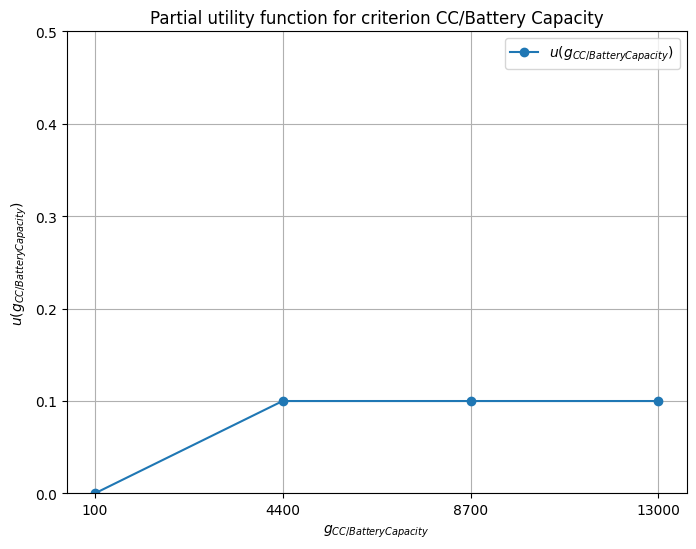

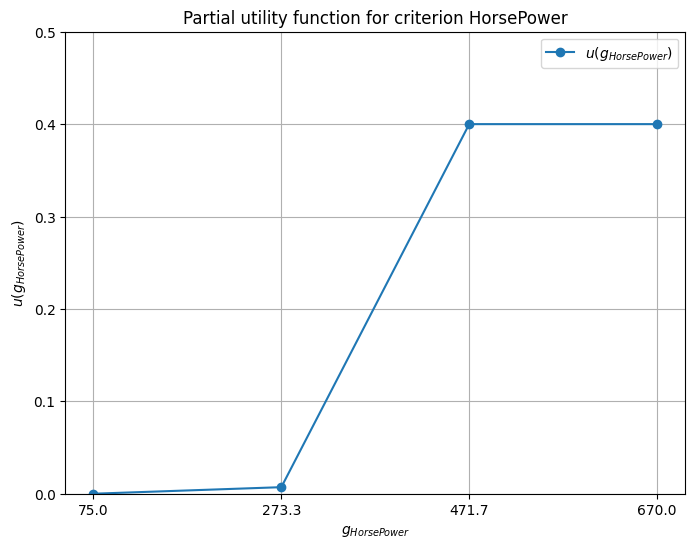

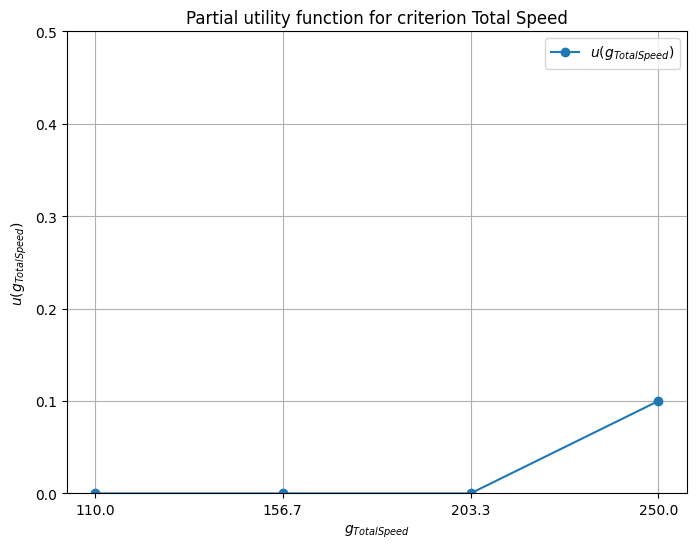

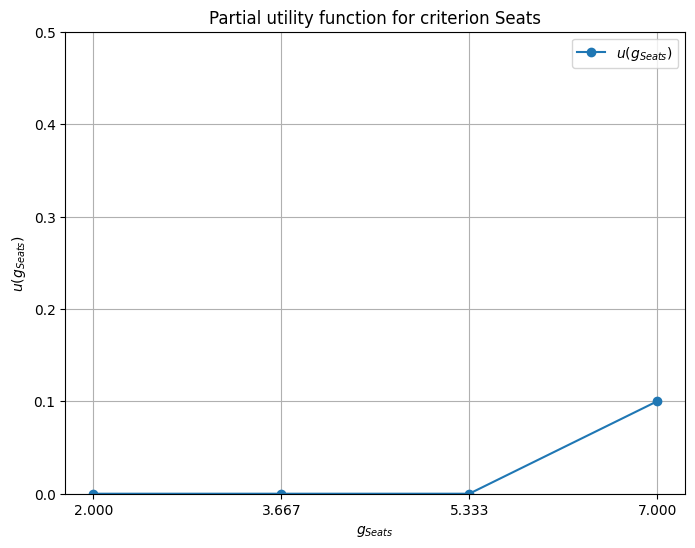

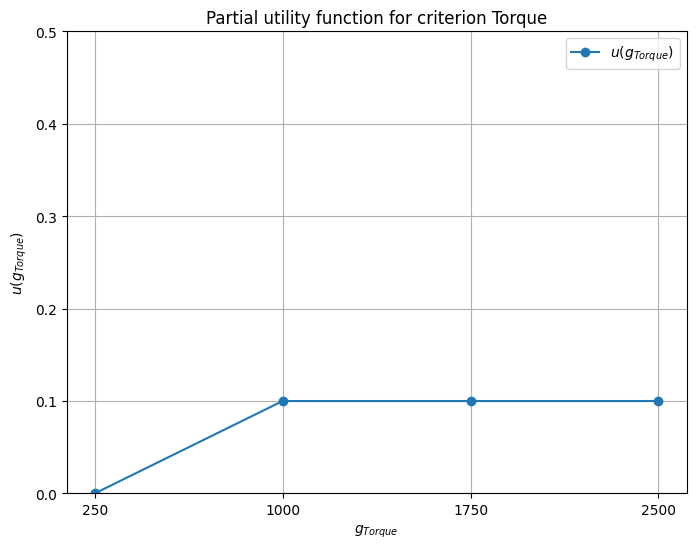

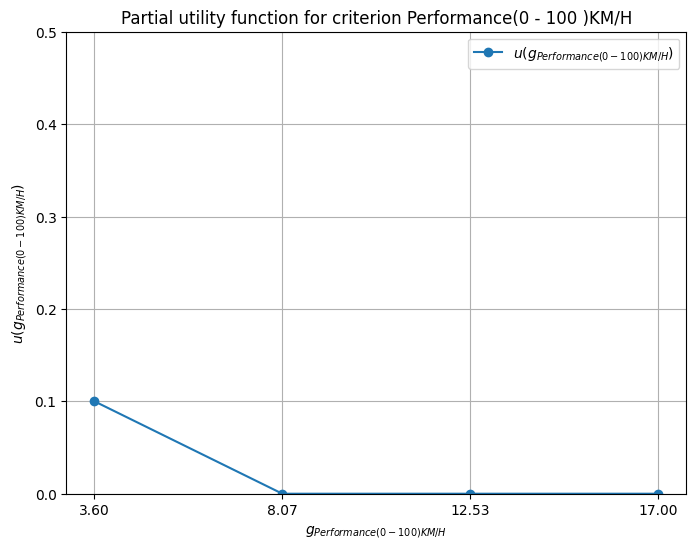

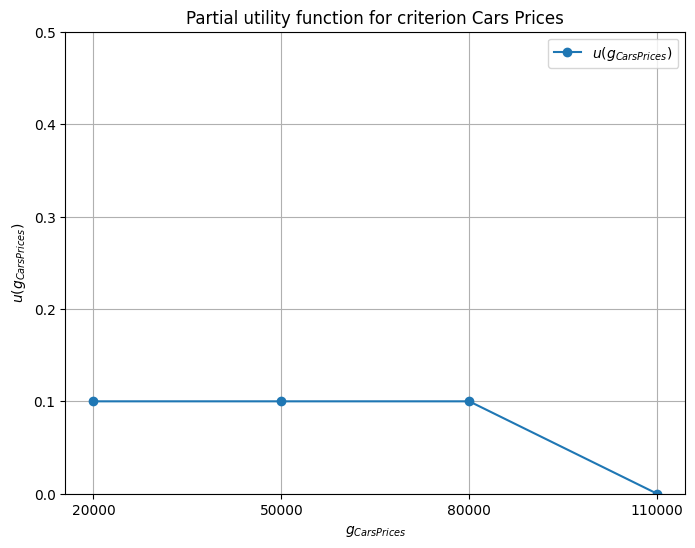

In [34]:
for criterion in criteria:
    plot_criterion(prob, u, criterion, criterion_values)